# 03 – Forecasting Models: Day-Ahead Forecasts

Dieses Notebook erzeugt die Forecasts für die spätere Bidding-Evaluation.

## Ziel

Wir trainieren verschiedene Forecasting-Modelle im **Day-Ahead-Setup**.  
Für die Prognose der Produktion zum Zeitpunkt \(t\) werden nur Informationen verwendet, die mindestens 24 Stunden vorher bekannt wären.

## Wichtig

Dieses Notebook bewertet die Modelle **nicht final über RMSE**.  
RMSE, MAE und Pinball Loss dienen nur zur deskriptiven Einordnung.

Der zentrale Vergleich erfolgt später in Notebook 04 über:

```text
Forecast → Bid → Profit / Newsvendor Loss
```

## Modellgruppen

### Point Forecasts
- Persistence 24h
- Elastic Net
- Random Forest
- Gradient Boosting

### Probabilistic Forecasts
- Quantile Regression
- Quantile Regression Forest (QRF)
- Quantile Gradient Boosting
- Quantile Neural Network


## 1. Setup und Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [FORECAST_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: C:\Users\felix\Documents\AI1\wind_bidding_project
Data path: C:\Users\felix\Documents\AI1\wind_bidding_project\data\processed\final_dataset.csv


## 2. Modell-Imports aus `src.models`

In [2]:
from src.data.gate_close_features import engineer_gate_close_features, get_gate_close_features
from src.models import (
    elastic_net,
    random_forest,
    gradient_boosting,
    quantile_regression,
    quantile_regression_forest,
    quantile_gradient_boosting,
    quantile_neural_network,
)


## 3. Daten laden

Erwartete Eingabedatei:

```text
data/processed/final_dataset.csv
```

Mindestens benötigte Spalten:

```text
timestamp
power
```

Optional:

```text
wind_speed
```


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
df.head()


Shape: (254067, 11)


,site,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,Schonungen,2014-01-02 00:00:00,249.833333,5.353333,0,3,1,0.000000,1.000000,0.433884,-0.900969
1,Schonungen,2014-01-02 01:00:00,356.600000,5.966667,1,3,1,0.258819,0.965926,0.433884,-0.900969
2,Schonungen,2014-01-02 02:00:00,357.900000,5.980000,2,3,1,0.500000,0.866025,0.433884,-0.900969
3,Schonungen,2014-01-02 03:00:00,256.266667,5.366667,3,3,1,0.707107,0.707107,0.433884,-0.900969
4,Schonungen,2014-01-02 04:00:00,223.900000,5.183333,4,3,1,0.866025,0.500000,0.433884,-0.900969


## 4. Day-Ahead Feature Engineering (Gate-Close-Referenzierung)

Alle Gebote für Tag D+1 werden um **12:00 Uhr Mittag** von Tag D abgegeben (EPEX Gate Close).
Deshalb wird jedes Feature relativ zum **Gate-Close-Zeitpunkt** berechnet:

$$\text{gate\_close}(t) = \text{midnight}(t) - 12\,\text{h} = \text{noon of day } D$$

Alle 24 Zielstunden teilen denselben Gate-Close und damit exakt dieselbe Informationsbasis.
Das vermeidet sowohl Data Leakage als auch die Inkonsistenz eines fixen relativen Lags
(lag\_36 war für Zielstunde 0 = 12 h Abstand, für Stunde 23 = 59 h Abstand).

In [4]:
# Engineer gate-close features using dedicated module
df_model = engineer_gate_close_features(df_model)

# Get feature list
FEATURES_DAY_AHEAD = get_gate_close_features()

# Filter to only features that exist in this dataset
FEATURES_DAY_AHEAD = [f for f in FEATURES_DAY_AHEAD if f in df_model.columns]

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

print(f"Using {len(FEATURES_DAY_AHEAD)} features")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

,site,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,...,energy_roll168_at_gate,energy_roll_std168_at_gate,wind_at_gate,wind_gate_m12h,wind_gate_m24h,wind_gate_m168h,wind_roll24_at_gate,wind_roll_std24_at_gate,wind_roll168_at_gate,wind_roll_std168_at_gate
0,Schonungen,2014-01-02 00:00:00,249.833333,5.353333,0,3,1,0.000000,1.000000,0.433884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Schonungen,2014-01-02 01:00:00,356.600000,5.966667,1,3,1,0.258819,0.965926,0.433884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Schonungen,2014-01-02 02:00:00,357.900000,5.980000,2,3,1,0.500000,0.866025,0.433884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Schonungen,2014-01-02 03:00:00,256.266667,5.366667,3,3,1,0.707107,0.707107,0.433884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Schonungen,2014-01-02 04:00:00,223.900000,5.183333,4,3,1,0.866025,0.500000,0.433884,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Feature-Set und Zielvariable

In [5]:
BASE_FEATURES = [
    "energy_at_gate",            # Produktion bei Gate-Close (12:00, Tag D)
    "energy_gate_m12h",          # Produktion 12h vor Gate-Close (00:00, Tag D)
    "energy_gate_m24h",          # Produktion 24h vor Gate-Close (12:00, Tag D-1)
    "energy_gate_m48h",          # Produktion 48h vor Gate-Close
    "energy_gate_m168h",         # Produktion 168h vor Gate-Close (gleiche Wochenstunde)
    "energy_roll24_at_gate",     # 24h-Mittelwert bis Gate-Close
    "energy_roll_std24_at_gate", # 24h-Standardabweichung bis Gate-Close
    "energy_roll168_at_gate",    # 168h-Mittelwert (Wochenmuster)
    "energy_roll_std168_at_gate",
    "hour_sin", "hour_cos",      # Zielstunde (zyklisch kodiert)
    "dow_sin",  "dow_cos",       # Ziel-Wochentag (zyklisch)
    "month",                     # Saisonalität
]

WIND_LAG_FEATURES = [f for f in [
    "wind_at_gate",
    "wind_gate_m12h",
    "wind_gate_m24h",
    "wind_gate_m168h",
    "wind_roll24_at_gate",
    "wind_roll_std24_at_gate",
    "wind_roll168_at_gate",
    "wind_roll_std168_at_gate",
] if f in df_model.columns]

FEATURES_DAY_AHEAD = BASE_FEATURES + WIND_LAG_FEATURES

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

X = df_model[FEATURES_DAY_AHEAD]
y = df_model[TARGET]

print("Number of observations:", len(df_model))
print("Number of features:", len(FEATURES_DAY_AHEAD))
print("Features:")
for f in FEATURES_DAY_AHEAD:
    print(f"  - {f}")
X.head()

Number of observations: 249540
Number of features: 22
Features:
  - energy_at_gate
  - energy_gate_m12h
  - energy_gate_m24h
  - energy_gate_m48h
  - energy_gate_m168h
  - energy_roll24_at_gate
  - energy_roll_std24_at_gate
  - energy_roll168_at_gate
  - energy_roll_std168_at_gate
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - month
  - wind_at_gate
  - wind_gate_m12h
  - wind_gate_m24h
  - wind_gate_m168h
  - wind_roll24_at_gate
  - wind_roll_std24_at_gate
  - wind_roll168_at_gate
  - wind_roll_std168_at_gate


,energy_at_gate,energy_gate_m12h,energy_gate_m24h,energy_gate_m48h,energy_gate_m168h,energy_roll24_at_gate,energy_roll_std24_at_gate,energy_roll168_at_gate,energy_roll_std168_at_gate,hour_sin,...,dow_cos,month,wind_at_gate,wind_gate_m12h,wind_gate_m24h,wind_gate_m168h,wind_roll24_at_gate,wind_roll_std24_at_gate,wind_roll168_at_gate,wind_roll_std168_at_gate
0,1.363067,0.347633,0.703733,0.307967,0.8763,0.511981,0.321471,0.723787,0.531124,0.000000,...,-0.900969,1,9.246667,6.156667,7.653333,7.916667,6.538611,1.276668,7.172163,1.856229
1,1.363067,0.347633,0.703733,0.307967,0.8763,0.511981,0.321471,0.723787,0.531124,0.258819,...,-0.900969,1,9.246667,6.156667,7.653333,7.916667,6.538611,1.276668,7.172163,1.856229
2,1.363067,0.347633,0.703733,0.307967,0.8763,0.511981,0.321471,0.723787,0.531124,0.500000,...,-0.900969,1,9.246667,6.156667,7.653333,7.916667,6.538611,1.276668,7.172163,1.856229
3,1.363067,0.347633,0.703733,0.307967,0.8763,0.511981,0.321471,0.723787,0.531124,0.707107,...,-0.900969,1,9.246667,6.156667,7.653333,7.916667,6.538611,1.276668,7.172163,1.856229
4,1.363067,0.347633,0.703733,0.307967,0.8763,0.511981,0.321471,0.723787,0.531124,0.866025,...,-0.900969,1,9.246667,6.156667,7.653333,7.916667,6.538611,1.276668,7.172163,1.856229


## 6. Zeitlicher Train-Test-Split

In [6]:
TEST_SIZE = 0.2

split_idx = int(len(df_model) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_timestamps = df_model.loc[X_test.index, "timestamp"].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Test period:", test_timestamps.min(), "bis", test_timestamps.max())


Train: (199632, 22) (199632,)
Test: (49908, 22) (49908,)
Test period: 2023-09-28 18:00:00 bis 2025-08-31 23:00:00


## 7. Hilfsfunktionen für deskriptive Forecast-Metriken

In [7]:

def evaluate_point_forecast(y_true, y_pred) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def add_point_metrics(rows: list[dict], model_name: str, y_true, y_pred) -> None:
    row = {"model": model_name}
    row.update(evaluate_point_forecast(y_true, y_pred))
    rows.append(row)


def clip_non_negative(values):
    """
    Ensure non-negative wind energy forecasts.
    Wind production cannot be negative.
    """
    return np.clip(np.asarray(values, dtype=float), 0, None)


def enforce_quantile_monotonicity(preds: pd.DataFrame) -> pd.DataFrame:
    """
    Enforce q10 <= q25 <= q50 <= q75 <= q90 row-wise.

    This is a pragmatic post-processing step to avoid quantile crossing
    when quantile models are trained independently.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        return preds.copy()

    fixed = preds.copy()
    fixed[quantile_cols] = np.sort(fixed[quantile_cols].to_numpy(), axis=1)
    return fixed


def check_quantile_monotonicity(preds: pd.DataFrame, model_name: str) -> None:
    """
    Print whether quantile predictions are monotonic.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        print(f"{model_name}: no quantile columns found.")
        return

    values = preds[quantile_cols].to_numpy()
    violations = np.sum(np.any(np.diff(values, axis=1) < 0, axis=1))

    if violations == 0:
        print(f"{model_name}: quantiles are monotonic.")
    else:
        print(f"{model_name}: fixed {violations} rows with quantile crossing.")


# Teil A – Point Forecast Models

Point Forecasts liefern genau einen Vorhersagewert pro Zeitpunkt.  
Sie werden später im Bidding als direktes Gebot interpretiert:

\[
b_t = \hat{y}_t
\]

Im finalen Vergleich werden sie nicht über RMSE gegen probabilistische Modelle ausgespielt, sondern über ihre wirtschaftliche Bidding-Performance.


## 8. Point Forecasts trainieren

In [8]:
point_metrics_rows = []

# Persistence (Gate): Vorhersage = Produktion zum Gate-Close-Zeitpunkt für alle 24h des Folgetags.
y_pred_persistence_gate = df_model.loc[X_test.index, "energy_at_gate"].to_numpy()
y_pred_persistence_gate = clip_non_negative(y_pred_persistence_gate)

en_model = elastic_net.train(
    X_train,
    y_train,
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42,
)
y_pred_elastic_net = elastic_net.predict(en_model, X_test)
y_pred_elastic_net = clip_non_negative(y_pred_elastic_net)

rf_model = random_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
)
y_pred_random_forest = random_forest.predict(rf_model, X_test)
y_pred_random_forest = clip_non_negative(y_pred_random_forest)

gb_model = gradient_boosting.train(
    X_train, y_train,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
y_pred_gradient_boosting = gradient_boosting.predict(gb_model, X_test)
y_pred_gradient_boosting = clip_non_negative(y_pred_gradient_boosting)

point_predictions = {
    "Persistence_gate":  y_pred_persistence_gate,
    "Elastic_Net":       y_pred_elastic_net,
    "Random_Forest":     y_pred_random_forest,
    "Gradient_Boosting": y_pred_gradient_boosting,
}

for model_name, y_pred in point_predictions.items():
    add_point_metrics(point_metrics_rows, model_name, y_test, y_pred)

point_metrics = pd.DataFrame(point_metrics_rows).sort_values("RMSE")
point_metrics

,model,MAE,RMSE,R2
3,Gradient_Boosting,0.495833,0.685049,0.181730
1,Elastic_Net,0.500428,0.689647,0.170709
2,Random_Forest,0.504524,0.694715,0.158476
0,Persistence_gate,0.515831,0.800407,-0.117057


## 9. Deskriptive Grafik: Point Forecast RMSE

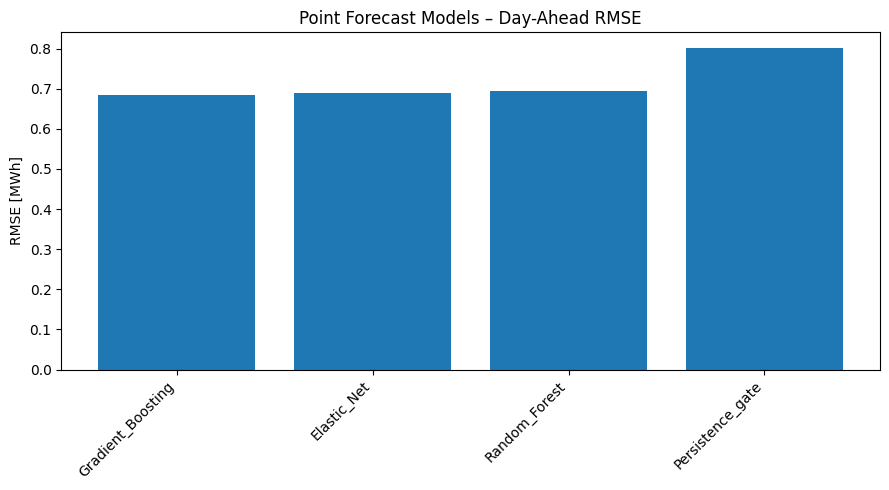

In [9]:
plot_df = point_metrics.sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE [MWh]")
plt.title("Point Forecast Models – Day-Ahead RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "point_forecast_rmse_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil B – Probabilistic Forecast Models

Probabilistische Modelle liefern mehrere Quantile pro Zeitpunkt.

Für das Newsvendor-Bidding ist das besonders relevant, weil je nach Kostenstruktur unterschiedliche Quantile als Gebot verwendet werden können.


## 10. Probabilistische Modelle trainieren

In [ ]:

QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)

prob_median_metrics_rows = []
pinball_rows = []

# Quantile Regression
qr_models = quantile_regression.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
)
qr_preds = quantile_regression.predict_all(qr_models, X_test)
qr_preds = enforce_quantile_monotonicity(qr_preds).clip(lower=0)
check_quantile_monotonicity(qr_preds, "Quantile Regression")

y_pred_qr_q50 = qr_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Regression_q50", y_test, y_pred_qr_q50)

qr_pinball = quantile_regression.evaluate_quantiles(y_test, qr_preds)
qr_pinball["model"] = "Quantile_Regression"
pinball_rows.append(qr_pinball)

# Quantile Regression Forest
qrf_model = quantile_regression_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
)
qrf_preds = quantile_regression_forest.predict_all(
    qrf_model,
    X_test,
    quantiles=QUANTILES,
)
qrf_preds = enforce_quantile_monotonicity(qrf_preds).clip(lower=0)
check_quantile_monotonicity(qrf_preds, "QRF")

y_pred_qrf_q50 = qrf_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "QRF_q50", y_test, y_pred_qrf_q50)

qrf_pinball = quantile_regression_forest.evaluate_quantiles(y_test, qrf_preds)
qrf_pinball["model"] = "QRF"
pinball_rows.append(qrf_pinball)

# Quantile Gradient Boosting
qgb_models = quantile_gradient_boosting.train(
    X_train, y_train,
    quantiles=QUANTILES,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test)
qgb_preds = enforce_quantile_monotonicity(qgb_preds).clip(lower=0)
check_quantile_monotonicity(qgb_preds, "Quantile Gradient Boosting")

y_pred_qgb_q50 = qgb_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Gradient_Boosting_q50", y_test, y_pred_qgb_q50)

qgb_pinball = quantile_gradient_boosting.evaluate_quantiles(y_test, qgb_preds)
qgb_pinball["model"] = "Quantile_Gradient_Boosting"
pinball_rows.append(qgb_pinball)

# Quantile Neural Network
qnn_model = quantile_neural_network.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
    hidden_layer_sizes=(64, 32),
    dropout=0.1,
    learning_rate=0.001,
    weight_decay=0.0001,
    batch_size=64,
    max_epochs=500,
    patience=30,
    random_state=42,
)
qnn_preds = quantile_neural_network.predict_all(qnn_model, X_test)
qnn_preds = enforce_quantile_monotonicity(qnn_preds).clip(lower=0)
check_quantile_monotonicity(qnn_preds, "Quantile Neural Network")

y_pred_qnn_q50 = qnn_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Neural_Network_q50", y_test, y_pred_qnn_q50)

qnn_pinball = quantile_neural_network.evaluate_quantiles(y_test, qnn_preds)
qnn_pinball["model"] = "Quantile_Neural_Network"
pinball_rows.append(qnn_pinball)

prob_median_metrics = pd.DataFrame(prob_median_metrics_rows).sort_values("RMSE")
pinball_metrics = pd.concat(pinball_rows, ignore_index=True)
pinball_metrics = pinball_metrics[["model", "quantile", "pinball_loss"]]

prob_median_metrics


## 11. Pinball Loss der probabilistischen Modelle

In [ ]:
pinball_metrics.sort_values(["quantile", "pinball_loss"])


,model,quantile,pinball_loss
15,Quantile_Neural_Network,0.10,0.150898
10,Quantile_Gradient_Boosting,0.10,0.152802
0,Quantile_Regression,0.10,0.152828
5,QRF,0.10,0.162316
16,Quantile_Neural_Network,0.25,0.348925
11,Quantile_Gradient_Boosting,0.25,0.355148
1,Quantile_Regression,0.25,0.356554
6,QRF,0.25,0.378078
17,Quantile_Neural_Network,0.50,0.574205
12,Quantile_Gradient_Boosting,0.50,0.579370


## 12. Deskriptive Grafik: Pinball Loss

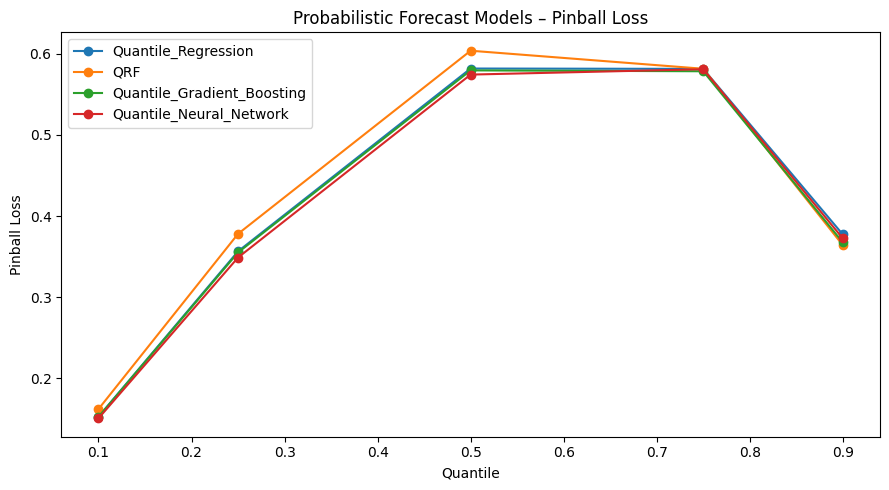

In [ ]:
plt.figure(figsize=(9, 5))

for model_name in pinball_metrics["model"].unique():
    subset = pinball_metrics[pinball_metrics["model"] == model_name].sort_values("quantile")
    plt.plot(
        subset["quantile"],
        subset["pinball_loss"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Quantile")
plt.ylabel("Pinball Loss")
plt.title("Probabilistic Forecast Models – Pinball Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "probabilistic_pinball_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Beispielgrafik: Quantile-Band

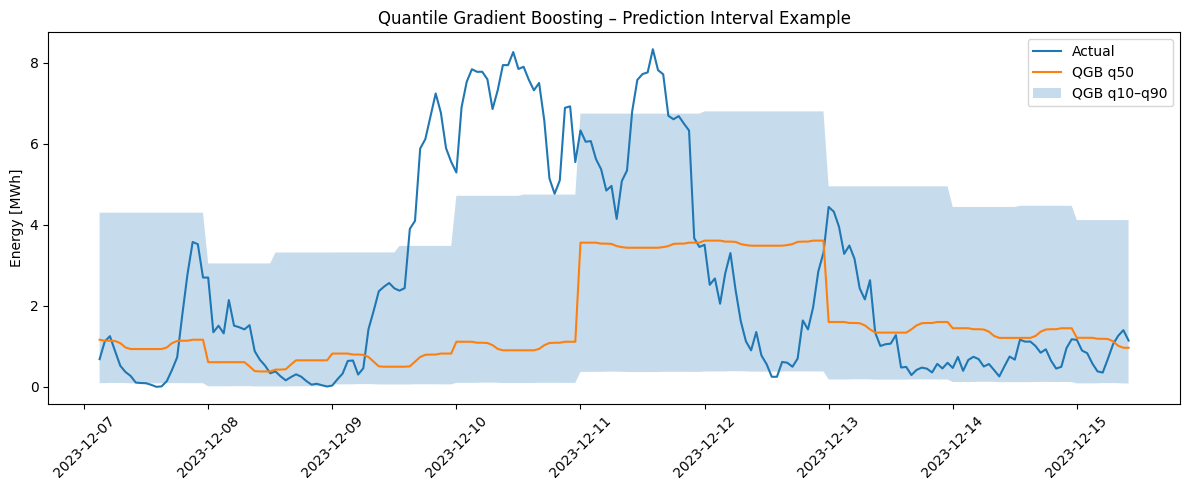

In [ ]:
plot_window = min(200, len(y_test))

plot_data = pd.DataFrame({
    "timestamp": test_timestamps.iloc[:plot_window],
    "actual": y_test.iloc[:plot_window].to_numpy(),
    "q10": qgb_preds["q10"].iloc[:plot_window].to_numpy(),
    "q50": qgb_preds["q50"].iloc[:plot_window].to_numpy(),
    "q90": qgb_preds["q90"].iloc[:plot_window].to_numpy(),
})

plt.figure(figsize=(12, 5))
plt.plot(plot_data["timestamp"], plot_data["actual"], label="Actual")
plt.plot(plot_data["timestamp"], plot_data["q50"], label="QGB q50")
plt.fill_between(
    plot_data["timestamp"],
    plot_data["q10"],
    plot_data["q90"],
    alpha=0.25,
    label="QGB q10–q90",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Quantile Gradient Boosting – Prediction Interval Example")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qgb_prediction_interval_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil C – Gemeinsame Forecast Outputs

## 14. Gemeinsames Predictions-DataFrame erstellen

In [ ]:
predictions = pd.DataFrame({
    "timestamp": test_timestamps.values,
    "y_true": y_test.to_numpy(),

    "persistence_gate": y_pred_persistence_gate,
    "elastic_net": y_pred_elastic_net,
    "random_forest": y_pred_random_forest,
    "gradient_boosting": y_pred_gradient_boosting,

    "quantile_regression_q10": qr_preds["q10"].to_numpy(),
    "quantile_regression_q25": qr_preds["q25"].to_numpy(),
    "quantile_regression_q50": qr_preds["q50"].to_numpy(),
    "quantile_regression_q75": qr_preds["q75"].to_numpy(),
    "quantile_regression_q90": qr_preds["q90"].to_numpy(),

    "qrf_q10": qrf_preds["q10"].to_numpy(),
    "qrf_q25": qrf_preds["q25"].to_numpy(),
    "qrf_q50": qrf_preds["q50"].to_numpy(),
    "qrf_q75": qrf_preds["q75"].to_numpy(),
    "qrf_q90": qrf_preds["q90"].to_numpy(),

    "qgb_q10": qgb_preds["q10"].to_numpy(),
    "qgb_q25": qgb_preds["q25"].to_numpy(),
    "qgb_q50": qgb_preds["q50"].to_numpy(),
    "qgb_q75": qgb_preds["q75"].to_numpy(),
    "qgb_q90": qgb_preds["q90"].to_numpy(),

    "qnn_q10": qnn_preds["q10"].to_numpy(),
    "qnn_q25": qnn_preds["q25"].to_numpy(),
    "qnn_q50": qnn_preds["q50"].to_numpy(),
    "qnn_q75": qnn_preds["q75"].to_numpy(),
    "qnn_q90": qnn_preds["q90"].to_numpy(),
})

print(predictions.shape)
predictions.head()

(13816, 26)


,timestamp,y_true,persistence_gate,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2023-12-07 03:00:00,0.683483,1.440683,1.735109,1.702471,1.694821,0.078341,0.407412,1.294931,2.480991,...,0.090291,0.349572,1.163363,2.377029,4.299858,0.154326,0.585495,1.683138,3.302083,4.969246
1,2023-12-07 04:00:00,1.120767,1.440683,1.710009,1.797413,1.694821,0.079038,0.400532,1.246877,2.384050,...,0.092044,0.349572,1.138926,2.377029,4.299858,0.163425,0.604497,1.690699,3.281041,4.922389
2,2023-12-07 05:00:00,1.251583,1.440683,1.680779,1.806225,1.694821,0.079564,0.391714,1.191615,2.283215,...,0.096253,0.349572,1.138926,2.377029,4.299858,0.170026,0.617865,1.694559,3.266536,4.892804
3,2023-12-07 06:00:00,0.879967,1.440683,1.649411,1.855865,1.694821,0.079881,0.381560,1.132910,2.185356,...,0.096253,0.349572,1.132180,2.377029,4.299858,0.171873,0.619271,1.683835,3.248603,4.875987
4,2023-12-07 07:00:00,0.521533,1.440683,1.618043,1.932694,1.694821,0.079968,0.370762,1.074762,2.097144,...,0.096253,0.349572,1.078533,2.364868,4.299858,0.167914,0.605561,1.656538,3.224323,4.868536


## 15. Beispielgrafik: Actual vs. ausgewählte Forecasts

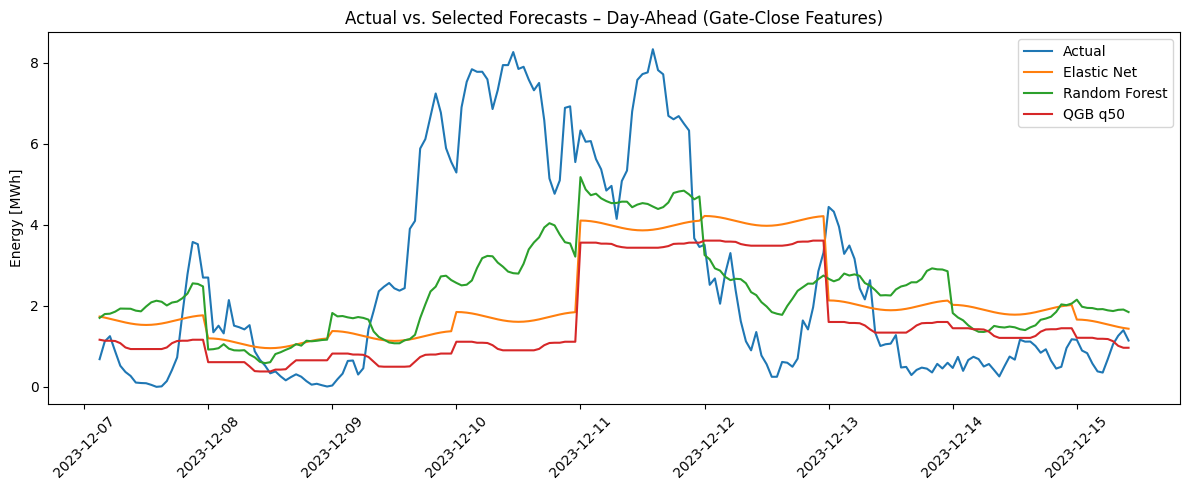

In [ ]:
plot_window = min(200, len(predictions))

plt.figure(figsize=(12, 5))

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["y_true"].iloc[:plot_window],
    label="Actual",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["elastic_net"].iloc[:plot_window],
    label="Elastic Net",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["random_forest"].iloc[:plot_window],
    label="Random Forest",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["qgb_q50"].iloc[:plot_window],
    label="QGB q50",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Actual vs. Selected Forecasts – Day-Ahead (Gate-Close Features)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_selected_forecasts_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## Hinweis zu xAI

Die erklärende Analyse der Modelle erfolgt nicht in diesem Forecasting-Notebook, sondern in Notebook 05.

Dort sollten insbesondere folgende Aspekte betrachtet werden:

- Koeffizienten von Elastic Net als interpretierbares Modell
- Feature Importances und SHAP für Random Forest, Gradient Boosting, QRF und Quantile Gradient Boosting
- Analyse von Zeitpunkten mit hohen Bidding-Verlusten aus Notebook 04

Notebook 03 erzeugt dafür nur die Forecasts, Modelle und Testfeatures.


## 16. Outputs speichern

In [ ]:
predictions_path = FORECAST_DIR / "predictions_day_ahead.csv"
features_path = FORECAST_DIR / "test_features_day_ahead.csv"

point_metrics_path = TABLES_DIR / "point_forecast_metrics_day_ahead.csv"
prob_median_metrics_path = TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv"
pinball_metrics_path = TABLES_DIR / "pinball_metrics_day_ahead.csv"

predictions.to_csv(predictions_path, index=False)
X_test.reset_index(drop=True).to_csv(features_path, index=False)

point_metrics.to_csv(point_metrics_path, index=False)
prob_median_metrics.to_csv(prob_median_metrics_path, index=False)
pinball_metrics.to_csv(pinball_metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", features_path)
print("Saved:", point_metrics_path)
print("Saved:", prob_median_metrics_path)
print("Saved:", pinball_metrics_path)


Saved: /Users/noahweis/wind_bidding_project/results/forecasts/predictions_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/forecasts/test_features_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/point_forecast_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/probabilistic_median_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/pinball_metrics_day_ahead.csv


## 17. Modelle speichern

In [ ]:
joblib.dump(en_model, MODELS_DIR / "elastic_net_day_ahead.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest_day_ahead.joblib")
joblib.dump(gb_model, MODELS_DIR / "gradient_boosting_day_ahead.joblib")

joblib.dump(qr_models, MODELS_DIR / "quantile_regression_day_ahead.joblib")
joblib.dump(qrf_model, MODELS_DIR / "qrf_day_ahead.joblib")
joblib.dump(qgb_models, MODELS_DIR / "quantile_gradient_boosting_day_ahead.joblib")
joblib.dump(qnn_model, MODELS_DIR / "quantile_neural_network_day_ahead.joblib")

print("Saved models to:", MODELS_DIR)


Saved models to: /Users/noahweis/wind_bidding_project/results/models


## 18. Zusammenfassung

In [ ]:
print("Point Forecast Metrics")
display(point_metrics)

print("Probabilistic Median Metrics")
display(prob_median_metrics)

print("Pinball Metrics")
display(pinball_metrics.sort_values(["quantile", "pinball_loss"]))


Point Forecast Metrics


,model,MAE,RMSE,R2
3,Gradient_Boosting,1.272480,1.682719,0.212914
1,Elastic_Net,1.263475,1.696554,0.199918
2,Random_Forest,1.281525,1.702768,0.194046
0,Persistence_gate,1.332470,2.042285,-0.159396


Probabilistic Median Metrics


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,1.148411,1.749907,0.148805
1,QRF_q50,1.207182,1.757135,0.141758
2,Quantile_Gradient_Boosting_q50,1.158739,1.767360,0.131741
0,Quantile_Regression_q50,1.163330,1.773976,0.125229


Pinball Metrics


,model,quantile,pinball_loss
15,Quantile_Neural_Network,0.10,0.150898
10,Quantile_Gradient_Boosting,0.10,0.152802
0,Quantile_Regression,0.10,0.152828
5,QRF,0.10,0.162316
16,Quantile_Neural_Network,0.25,0.348925
11,Quantile_Gradient_Boosting,0.25,0.355148
1,Quantile_Regression,0.25,0.356554
6,QRF,0.25,0.378078
17,Quantile_Neural_Network,0.50,0.574205
12,Quantile_Gradient_Boosting,0.50,0.579370
